In [5]:
from diffusion_hash_inv.config import MainConfig, HashConfig, MessageConfig, OutputConfig, Byte2RGBConfig
from diffusion_hash_inv.main import MainEP
from diffusion_hash_inv.utils import FileIO
from diffusion_hash_inv.main import RuntimeConfig

length = 16
iteration = 2**length

main_cfg = MainConfig(
    verbose_flag=False,
    clean_flag=True,
    debug_flag=False,
    make_image_flag=False,
)
hash_cfg = HashConfig(
    hash_alg="md5",
    length=length,
)
message_cfg = MessageConfig(
    message_flag=False,
    length=length,
    random_flag=False,
    seed_flag=True,
)
output_cfg = OutputConfig()
byte2rgb_cfg = Byte2RGBConfig()
runtime_cfg = RuntimeConfig(
    main=main_cfg,
    message=message_cfg,
    hash=hash_cfg,
    output=output_cfg,
    rgb=byte2rgb_cfg,
)


io_controller = FileIO(main_config=main_cfg, output_cfg=output_cfg)

Clearing generated files...



In [6]:
output_cfg.data_dir

PosixPath('/Users/choisoonwook/Experiments_local/Diffusion_HASH_inverse/data')

In [ ]:
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torchvision.transforms.functional as F
from torch.utils.data import ConcatDataset, Subset
import torch

transform = transforms.Compose([
    transforms.Lambda(lambda img: F.rotate(img, -90)),
    transforms.Lambda(lambda img: F.hflip(img)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))

])
train_dataset = datasets.EMNIST(root=output_cfg.data_dir, split='byclass', download=True, transform=transform, train=True)
test_dataset = datasets.EMNIST(root=output_cfg.data_dir, split='byclass', download=True, transform=transform, train=False)
full_dataset = ConcatDataset([train_dataset, test_dataset])
dataloader = DataLoader(train_dataset, batch_size=128, shuffle=False)
print(f"Length of train dataset: {len(train_dataset)}")
print(f"Length of test dataset:  {len(test_dataset)}")
print(f"Length of full dataset:  {len(full_dataset)}")

Length of train dataset: 697932
Length of test dataset:  116323
Length of full dataset:  814255


In [17]:
_digits = [chr(i) for i in range(ord("0"), ord("9") + 1)]
_upper = [chr(i) for i in range(ord("A"), ord("Z") + 1)]
_lower = [chr(i) for i in range(ord("a"), ord("z") + 1)]
dataset_dict = {}

target_chars = _digits + _upper
target_labels = torch.tensor([train_dataset.classes.index(ch) for ch in target_chars])

train_mask = torch.isin(train_dataset.targets, target_labels)
test_mask = torch.isin(test_dataset.targets, target_labels)

train_indices = train_mask.nonzero(as_tuple=True)[0].tolist()
test_indices = test_mask.nonzero(as_tuple=True)[0].tolist()

train_subset = Subset(train_dataset, train_indices)
test_subset = Subset(test_dataset, test_indices)
sub_dataset = ConcatDataset([train_subset, test_subset])


print("", len(sub_dataset))

 623257


In [ ]:
_sum = 0
for ch in target_chars:
    label = train_dataset.classes.index(ch)
    _train_indices = (train_dataset.targets == label).nonzero(as_tuple=True)[0].tolist()
    _test_indices = (test_dataset.targets == label).nonzero(as_tuple=True)[0].tolist()
    _train_subset = Subset(train_dataset, _train_indices)
    _test_subset = Subset(test_dataset, _test_indices)
    dataset_dict[ch] = ConcatDataset([_train_subset, _test_subset])
    _sum += len(dataset_dict[ch])


for _k, _v in dataset_dict.items():
    print(f"{_k} 개수: {len(_v)}")

print(f"총 개수: {_sum}")

0 개수: 40363
1 개수: 44704
2 개수: 40072
3 개수: 41112
4 개수: 39154
5 개수: 36606
6 개수: 39937
7 개수: 41893
8 개수: 39579
9 개수: 39533
A 개수: 7469
B 개수: 4526
C 개수: 11833
D 개수: 5341
E 개수: 5785
F 개수: 10622
G 개수: 2964
H 개수: 3673
I 개수: 13994
J 개수: 4388
K 개수: 2850
L 개수: 5886
M 개수: 10487
N 개수: 9588
O 개수: 29139
P 개수: 9744
Q 개수: 3018
R 개수: 5882
S 개수: 24272
T 개수: 11396
U 개수: 14604
V 개수: 5433
W 개수: 5501
X 개수: 3203
Y 개수: 5541
Z 개수: 3165
총 개수: 623257
최소 개수: 2850
최대 개수: 44704
평균 개수: 17312.69
표준편차: 15265.81


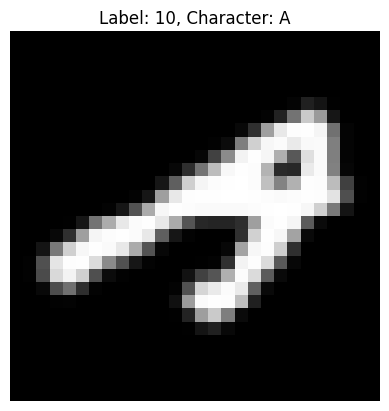

In [26]:
a_dataset = dataset_dict["A"]
img, label = a_dataset[0]
plt.imshow(img.squeeze(0), cmap="gray")
plt.title(f"Label: {label}, Character: {train_dataset.classes[label]}")
plt.axis("off")
plt.show()

torch.Size([128, 1, 28, 28])
torch.Size([128])


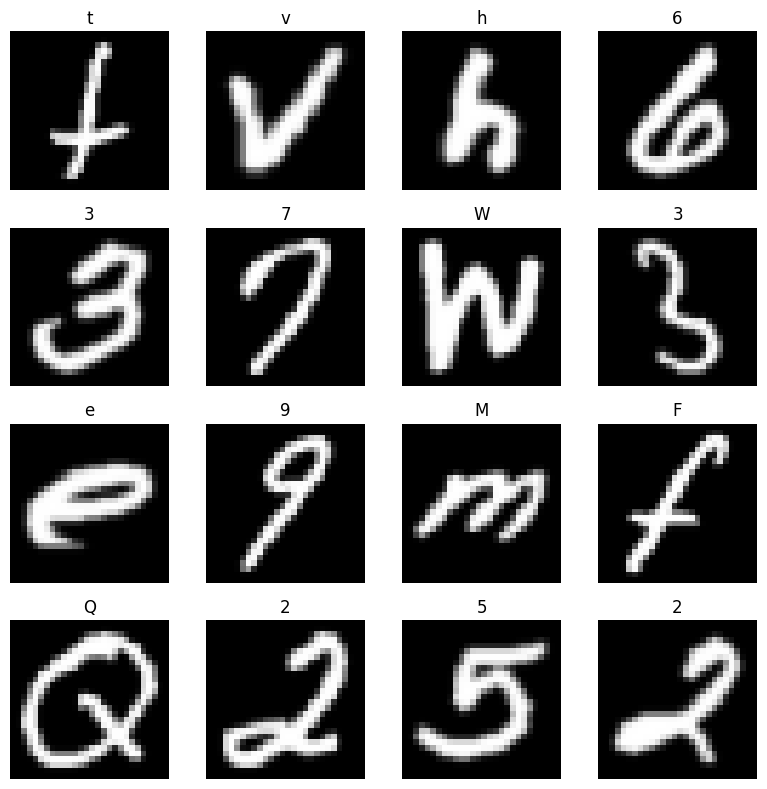

In [ ]:
images, labels = next(iter(dataloader))

print(images.shape)  # torch.Size([16, 1, 28, 28])

print(labels.shape)  # torch.Size([16])

plt.figure(figsize=(8, 8))

i = 16
for _i in range(i, i + 16):

    plt.subplot(4, 4, _i - i + 1)
    img_show = images[_i] * 0.5 + 0.5

    plt.imshow(img_show.squeeze(0), cmap="gray")

    plt.title(train_dataset.classes[labels[_i]])

    plt.axis("off")

plt.tight_layout()

plt.show()